<a href="https://colab.research.google.com/github/smkim0508/cos484-notes/blob/main/A3P3_Neural_Machine_Translation_(COS484_S2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook for Programming in Problem 3
Welcome to the programming portion of the assignment! Each assignment throughout the semester will have a written portion and a programming portion. We will be using [Google Colab](https://colab.research.google.com/notebooks/intro.ipynb#recent=true), so if you have never used it before, take a quick look through this introduction: [Working with Google Colab](https://docs.google.com/document/d/1LlnXoOblXwW3YX-0yG_5seTXJsb3kRdMMRYqs8Qqum4/edit?usp=sharing).

## Learning Objectives
In this problem, we will use [PyTorch](https://pytorch.org/) to implement a sequence-to-sequence (seq2seq) transformer model to build a nerual machine translation (NMT) system, which translates from French to English.

## Installing Packages

Install PyTorch using pip. See [https://pytorch.org/](https://pytorch.org/) if you want to install it on your computer.
In addition, we will also be needing [huggingface](https://huggingface.co/)'s `transformers` and `datasets` libraries, and [nltk](https://www.nltk.org/) to compute the BLEU score.

In [2]:
import torch

## Download NMT data

You need to first download and then unzip the data for NMT, which contains pairs of parallel sentences from the link below:
* Resources: https://princeton-nlp.github.io/cos484/assignments/a3/resources.zip

In [3]:
!wget https://princeton-nlp.github.io/cos484/assignments/a3/resources.zip
!unzip resources.zip

--2026-04-01 23:01:09--  https://princeton-nlp.github.io/cos484/assignments/a3/resources.zip
Resolving princeton-nlp.github.io (princeton-nlp.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to princeton-nlp.github.io (princeton-nlp.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 257538 (252K) [application/x-zip-compressed]
Saving to: ‘resources.zip’

resources.zip       100%[===================>] 251.50K  --.-KB/s    in 0.003s  

2026-04-01 23:01:09 (91.3 MB/s) - ‘resources.zip’ saved [257538/257538]

Archive:  resources.zip
   creating: resources/
   creating: resources/parallel_en_fr_corpus/
  inflating: resources/parallel_en_fr_corpus/dataset_dict.json  
   creating: resources/parallel_en_fr_corpus/test/
  inflating: resources/parallel_en_fr_corpus/test/dataset.arrow  
  inflating: resources/parallel_en_fr_corpus/test/dataset_info.json  
  inflating: resources/parallel_en_fr_corpus/test/state.json  

## Data Loading and Tokenization
You will need to write code to load and tokenize the data for NMT.


The parallel data `parallel_en_fr_corpus` is provided as huggingface datasets, one for each split of `train`, `validation` and `test`. You can load it via the `load_from_disk` method and inspect its features. If you'd like to know more about these dataset objects, have a look at [this tutorial](https://huggingface.co/docs/datasets/access).

In [4]:
# dataloading, just checks that the data was downloaded properly

from datasets import load_from_disk
from tokenizers import ByteLevelBPETokenizer

# the data downloaded in previous step
data_dir = "resources"

train_dataset = load_from_disk(f"{data_dir}/parallel_en_fr_corpus/train")
val_dataset = load_from_disk(f"{data_dir}/parallel_en_fr_corpus/validation")
test_dataset = load_from_disk(f"{data_dir}/parallel_en_fr_corpus/test")

print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['text_en', 'text_fr'],
    num_rows: 8701
})
{'text_en': 'i m tough .', 'text_fr': 'je suis dure .'}


In [5]:
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text_en', 'text_fr'],
    num_rows: 485
})
Dataset({
    features: ['text_en', 'text_fr'],
    num_rows: 486
})


You are also provided with two pre-trained tokenizers for the source and target languages, `tokenizer_fr` and `tokenizer_en`, respectively, which can be loaded with the hugginface transformers library. [This tutorial](https://huggingface.co/docs/transformers/preprocessing#natural-language-processing) provides an introduction to using pre-trained tokenizers and the powerful `AutoTokenizer` class. The tokenizers are based on byte-pair encodings which break words into smaller units. This is aimed at reducing the sparsity of words, as subwords can be shared between different rare words. If you are interested in learning more, see the paper [Neural Machine Translation of Rare Words with Subword Units](https://www.aclweb.org/anthology/P16-1162.pdf).

In [6]:
from transformers import AutoTokenizer

# load pre-trained tokenizers
fr_tokenizer = AutoTokenizer.from_pretrained("resources/tokenizer_fr")
en_tokenizer = AutoTokenizer.from_pretrained("resources/tokenizer_en")

# inspect vocab sizes and special tokens
print("FR vocab size:", fr_tokenizer.vocab_size)
print("EN vocab size:", en_tokenizer.vocab_size)
print("special tokens:", en_tokenizer.special_tokens_map)
print("pad id:", en_tokenizer.pad_token_id)
print("bos id:", en_tokenizer.bos_token_id)
print("eos id:", en_tokenizer.eos_token_id)

sample = train_dataset[0]
fr_encoded = fr_tokenizer(sample["text_fr"])
en_encoded = en_tokenizer(sample["text_en"])

print("FR tokens:", fr_tokenizer.convert_ids_to_tokens(fr_encoded["input_ids"]))
print("EN tokens:", en_tokenizer.convert_ids_to_tokens(en_encoded["input_ids"]))

FR vocab size: 3200
EN vocab size: 3200
special tokens: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}
pad id: 3
bos id: 1
eos id: 2
FR tokens: ['<s>', '▁je', '▁suis', '▁dure', '▁.', '</s>']
EN tokens: ['<s>', '▁i', '▁m', '▁tough', '▁.', '</s>']


You should implement a function to convert the entire dataset to token ids.

In [7]:
def tokenize_dataset(dataset, fr_tokenizer, en_tokenizer):
    """
    Convert a dataset split to token ids for both languages.
    Uses dataset.map for efficient batched processing.
    Returns the dataset with added columns input_ids_fr and input_ids_en.
    """
    def tokenize_batch(batch):
        """
        Tokenize a batch of French and English sentences.
        Returns dict with token id lists for each language.
        """
        fr_encoded = fr_tokenizer(batch["text_fr"], truncation=False)
        en_encoded = en_tokenizer(batch["text_en"], truncation=False)
        return {
            "input_ids_fr": fr_encoded["input_ids"],
            "input_ids_en": en_encoded["input_ids"],
        }

    return dataset.map(tokenize_batch, batched=True)

# tokenize all splits
train_tokenized = tokenize_dataset(train_dataset, fr_tokenizer, en_tokenizer)
val_tokenized = tokenize_dataset(val_dataset, fr_tokenizer, en_tokenizer)
test_tokenized = tokenize_dataset(test_dataset, fr_tokenizer, en_tokenizer)

# sanity check
print(train_tokenized[0]["input_ids_fr"])
print(train_tokenized[0]["input_ids_en"])
print("num train examples:", len(train_tokenized))

Map:   0%|          | 0/8701 [00:00<?, ? examples/s]

Map:   0%|          | 0/485 [00:00<?, ? examples/s]

Map:   0%|          | 0/486 [00:00<?, ? examples/s]

[1, 47, 60, 1449, 36, 2]
[1, 37, 42, 1044, 35, 2]
num train examples: 8701


In [8]:
# main dataloader class to pre-process data

import torch
from torch.utils.data import Dataset, DataLoader

PAD_ID = en_tokenizer.pad_token_id # 3
IGNORE_INDEX = -100 # used to ignore pad positions in cross entropy loss


class NMTDataset(Dataset):
    """
    Thin wrapper around a HuggingFace tokenized dataset split.
    Each item is a dict with input_ids_fr and input_ids_en as tensors.
    """

    # uses the HF dataset for init
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    # helper to return number of samples in the data.
    def __len__(self):
        return len(self.dataset)

    # helper to get input_ids_fr and input_ids_en, each as a simple simple list
    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "input_ids_fr": item["input_ids_fr"],
            "input_ids_en": item["input_ids_en"],
        }


def collate_fn(batch):
    """
    Main helper to collates a list of examples into a padded batch.

    Encoder side:
    - pads input_ids_fr to the longest FR sequence in the batch.
    - builds encoder_padding_mask: True where the token is <pad>.

    Decoder side:
    - decoder_input_ids: input_ids_en with the last token dropped (drops </s>).
    - labels: input_ids_en with the first token dropped (drops <s>).
    - pads both to the longest EN sequence in the batch.
    - builds decoder_padding_mask: True where the token is <pad>.
    - sets label positions that are <pad> to IGNORE_INDEX (-100).

    Takes batch (dict) of eng and french sentences as input.

    Returns a dict of tensors ready for the model.
    """
    fr_seqs = [item["input_ids_fr"] for item in batch]
    en_seqs = [item["input_ids_en"] for item in batch]

    # decoder input drops </s> (last token), labels drop <s> (first token)
    dec_inputs = [seq[:-1] for seq in en_seqs]
    labels = [seq[1:] for seq in en_seqs]

    def pad_sequences(seqs, pad_id):
        """
        Helper to pad a list of sequences to the length of the longest one.
        Returns a (batch_size, max_len) tensor.
        """
        max_len = max(len(s) for s in seqs)
        padded = [s + [pad_id] * (max_len - len(s)) for s in seqs]
        return torch.tensor(padded, dtype=torch.long)

    encoder_input_ids = pad_sequences(fr_seqs, PAD_ID)
    decoder_input_ids = pad_sequences(dec_inputs, PAD_ID)
    label_ids = pad_sequences(labels, PAD_ID)

    # padding masks: True at positions that should be ignored in attention
    encoder_padding_mask = encoder_input_ids.eq(PAD_ID) # (B, src_len)
    decoder_padding_mask = decoder_input_ids.eq(PAD_ID) # (B, tgt_len)

    # replace pad positions in labels with IGNORE_INDEX for cross entropy
    label_ids = label_ids.masked_fill(label_ids.eq(PAD_ID), IGNORE_INDEX)

    return {
        "encoder_input_ids": encoder_input_ids, # (B, src_len)
        "encoder_padding_mask": encoder_padding_mask, # (B, src_len)
        "decoder_input_ids": decoder_input_ids, # (B, tgt_len)
        "decoder_padding_mask": decoder_padding_mask, # (B, tgt_len)
        "labels": label_ids, # (B, tgt_len)
    }


# wrap tokenized HuggingFace datasets
train_ds = NMTDataset(train_tokenized)
val_ds   = NMTDataset(val_tokenized)
test_ds  = NMTDataset(test_tokenized)

# build dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# sanity check: inspect one batch
batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")

encoder_input_ids: shape=torch.Size([64, 16]), dtype=torch.int64
encoder_padding_mask: shape=torch.Size([64, 16]), dtype=torch.bool
decoder_input_ids: shape=torch.Size([64, 11]), dtype=torch.int64
decoder_padding_mask: shape=torch.Size([64, 11]), dtype=torch.bool
labels: shape=torch.Size([64, 11]), dtype=torch.int64


## Transformer model for NMT

You should implement a encoder-decoder transformer model. This includes:
* **MultiHeadAttention Layers**: A class that initializes the multi-head attention layer and has a forward function to compute scaled dot-product attention and returns the output of the attention layer.
* **Embedding Layers**: A class that defines both the token embeddings and positional embeddings, which are added together to form the final embedding. This class should have functions to compute the logits for the next token prediction given the decoder output, and to compute the embeddings for the input tokens.
* **Transformer Blocks**: A class that defins a single Transformer block including the multi-head attention layers and feedforward layers, which can be either for the encoder or the decoder. This class should have a forward function that works either for the encoder or the decoder.
* **EncoderDecoderModel**: A class that defines a encoder-decoder transformer model which can be used for NMT.

For your MultiHeadAttention, your `MultiHeadAttention.forward()` should return a tuple of `(layer_output, attention_weights)`, where `attention_weights` has shape `(batch_size, num_heads, num_query_tokens, num_key_tokens)`. Your `forward_decoder()` should accept an optional flag `return_attention_weights: bool = False` and, when set to `True`, return the cross-attention weights from each decoder layer as a list of tensors in addition to the logits. You will need this to extract and visualize the cross-attention weights in Question (d).

For your EncoderDecoderModel, you can use these architecture hyperparameters without modifications:
* hidden_size: 32
* intermediate_size: 128 (32 * 4)
* num_attention_heads: 4
* num_encoder_layers: 3
* num_decoder_layers: 3
* max_sequence_length: 32
* hidden_dropout_prob: 0.1
* FFN activation: ReLU
* norm placement: post-norm
* attention weight dropout: none
* embedding dropout: none
* weight tying: none

In [9]:
import torch
import torch.nn as nn
import math


class MultiHeadAttention(nn.Module):
    """
    Multi-head scaled dot-product attention.
    Supports self-attention and cross-attention.
    No Python loops over heads; all heads are computed in parallel via reshape.
    """

    def __init__(self, hidden_size, num_attention_heads):
        super().__init__() # init the neural net parent
        # NOTE: we ensure that hidden size is divisible by number of attention heads to avoid loss/messy dims
        assert hidden_size % num_attention_heads == 0, "hidden_size must be divisible by num_attention_heads"

        self.hidden_size = hidden_size # total embedding dim d
        self.num_heads = num_attention_heads # num attention heads H
        self.head_dim = hidden_size // num_attention_heads # d_H = d / H

        # query, key, value projections: each maps d -> d
        self.q_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.k_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v_proj = nn.Linear(hidden_size, hidden_size, bias=False)

        # output projection: maps concatenated heads back to d
        self.out_proj = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, query, key, value, padding_mask=None, causal_mask=False):
        """
        Forward pass through the multi-head attention layer.
        - query: (B, T_q, d) tensor of query vectors.
        - key: (B, T_k, d) tensor of key vectors.
        - value: (B, T_k, d) tensor of value vectors.
        - padding_mask: (B, T_k) bool tensor; True at pad positions to mask.
        - causal_mask: if True, applies causal masking over T_q x T_k.

        Returns output (B, T_q, d) and attention weights (B, H, T_q, T_k).
        """
        B, T_q, _ = query.shape
        T_k = key.shape[1]

        # project and reshape to (B, H, T, d_H)
        Q = self.q_proj(query).view(B, T_q, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key).view(B, T_k, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, T_k, self.num_heads, self.head_dim).transpose(1, 2)

        # scaled dot-product scores: (B, H, T_q, T_k)
        scale = math.sqrt(self.head_dim)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale

        # apply padding mask: True positions get -inf so they vanish after softmax
        if padding_mask is not None:
            # padding_mask: (B, T_k) -> (B, 1, 1, T_k) for broadcasting
            scores = scores.masked_fill(padding_mask[:, None, None, :], float("-inf"))

        # apply causal mask: position i cannot attend to j > i
        if causal_mask:
            # upper triangle (above diagonal) is masked
            causal = torch.ones(T_q, T_k, dtype=torch.bool, device=query.device)
            causal = torch.triu(causal, diagonal=1) # (T_q, T_k)
            scores = scores.masked_fill(causal[None, None, :, :], float("-inf"))

        # softmax over key dimension to get attention weights
        attn_weights = torch.softmax(scores, dim=-1) # (B, H, T_q, T_k)

        # weighted sum of values (B, H, T_q, d_H)
        context = torch.matmul(attn_weights, V)

        # concatenate heads (B, T_q, H * d_H) = (B, T_q, d) to produce dim d on last dim for tensor
        context = context.transpose(1, 2).contiguous().view(B, T_q, self.hidden_size)

        # final projesction to get output
        output = self.out_proj(context) # (B, T_q, d)

        return output, attn_weights

Before moving on to the other modules, you should also implement a sanity check for your attention implementation:
1. Check the dimensions of the output of the layer and
2. Plot the attention weights to some toy embedding inputs.


You can assume that the last token in the encoder and the last two tokens in the decoder are pad tokens.

encoder self-attn output shape: torch.Size([2, 6, 32])
decoder self-attn output shape: torch.Size([2, 5, 32])
decoder cross-attn output shape: torch.Size([2, 5, 32])
encoder attn weights shape: torch.Size([2, 4, 6, 6])
decoder self-attn weights shape: torch.Size([2, 4, 5, 5])
decoder cross-attn weights shape: torch.Size([2, 4, 5, 6])


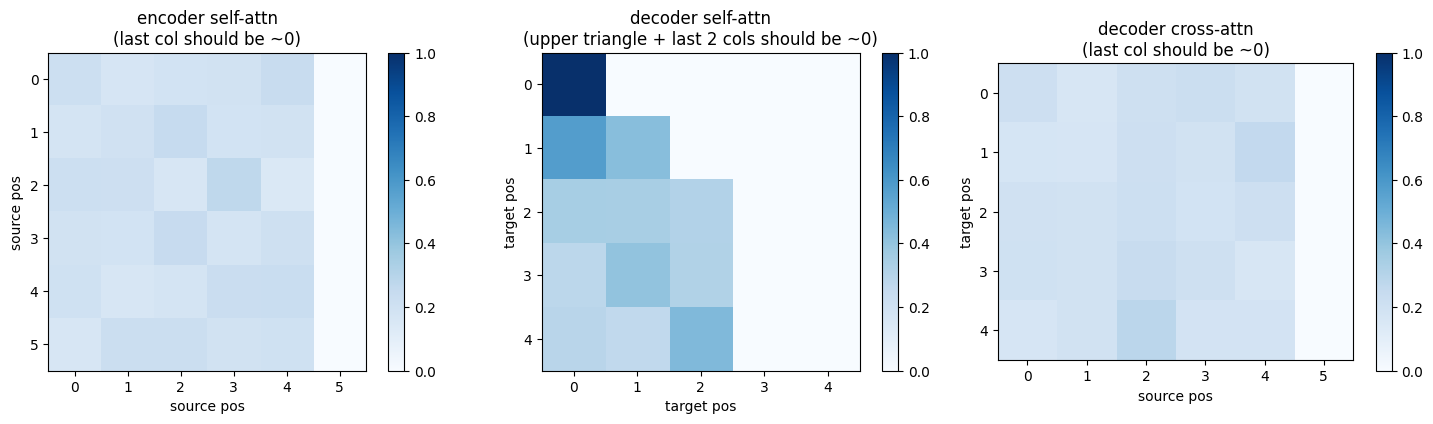

plot saved to attention_sanity_check.png


In [10]:
# perform sanity check on MultiHeadAttention layer

import matplotlib.pyplot as plt

def sanity_check_attention():
    """
    Helper for sanity check for MultiHeadAttention.
    - Checks output shapes and plots attention weights for encoder and decoder.
    - Assumes last token in encoder input is a pad token.
    - Assumes last two tokens in decoder input are pad tokens.
    """
    torch.manual_seed(42)

    # hyperparams for testing
    hidden_size = 32
    num_heads = 4
    B, T_enc, T_dec = 2, 6, 5

    # init multi head attention
    mha = MultiHeadAttention(hidden_size, num_heads)
    mha.eval()

    # test embeddings
    enc_input = torch.randn(B, T_enc, hidden_size)
    dec_input = torch.randn(B, T_dec, hidden_size)

    # NOTE: last token in encoder is pad, last two in decoder are pad
    enc_padding_mask = torch.zeros(B, T_enc, dtype=torch.bool)
    enc_padding_mask[:, -1] = True # (B, T_enc)
    dec_padding_mask = torch.zeros(B, T_dec, dtype=torch.bool)
    dec_padding_mask[:, -2:] = True # (B, T_dec)

    with torch.no_grad():
        # encoder self-attention: doesn't have causal mask
        enc_out, enc_attn = mha(
            enc_input, enc_input, enc_input,
            padding_mask=enc_padding_mask,
            causal_mask=False,
        )

        # decoder self-attention: has causal mask + decoder padding mask
        dec_self_out, dec_self_attn = mha(
            dec_input, dec_input, dec_input,
            padding_mask=dec_padding_mask,
            causal_mask=True,
        )

        # decoder cross-attention: queries from decoder, keys/values from encoder
        dec_cross_out, dec_cross_attn = mha(
            dec_input, enc_input, enc_input,
            padding_mask=enc_padding_mask,
            causal_mask=False,
        )

    # test 1: check output shapes
    print("encoder self-attention output shape:", enc_out.shape) # (B, T_enc, d)
    print("decoder self-attention output shape:", dec_self_out.shape) # (B, T_dec, d)
    print("decoder cross-attention output shape:", dec_cross_out.shape) # (B, T_dec, d)
    print("encoder attention weights shape:", enc_attn.shape) # (B, H, T_enc, T_enc)
    print("decoder self-attention weights shape:", dec_self_attn.shape) # (B, H, T_dec, T_dec)
    print("decoder cross-attention weights shape:", dec_cross_attn.shape) # (B, H, T_dec, T_enc)

    # test 2: plot attention weights for first example in batch, averaged over heads
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    plots = [
        # we expect last col to be 0
        (enc_attn[0].mean(0), "encoder self-attention", "source pos", "source pos"),
        # we expect upper triangular shape with last 2 cols 0
        (dec_self_attn[0].mean(0), "decoder self-attention", "target pos", "target pos"),
        # we expect last col to be 0
        (dec_cross_attn[0].mean(0), "decoder cross-attention", "source pos", "target pos"),
    ]

    for ax, (weights, title, xlabel, ylabel) in zip(axes, plots):
        im = ax.imshow(weights.numpy(), vmin=0, vmax=1, cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

# run the sanity check
sanity_check_attention()

In [11]:
# main embedding layer

class EmbeddingLayer(nn.Module):
    """
    Combines token and positional embeddings for encoder or decoder input.
    Also provides a logit projection for next-token prediction.
    Weight tying is not used; W_out is a separate parameter from the token embedding.
    """

    def __init__(self, vocab_size, hidden_size, max_sequence_length):
        """
        Args:
            - vocab_size: number of tokens in the vocabulary V.
            - hidden_size: embedding dimension d.
            - max_sequence_length: maximum sequence length N.
        """
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.position_embeddings = nn.Embedding(max_sequence_length, hidden_size)

        # separate output projection; not tied to token_embeddings
        self.out_proj = nn.Linear(hidden_size, vocab_size, bias=False)

    def embed(self, input_ids):
        """
        Computes the sum of token and positional embeddings.

        Args:
            - input_ids: (B, T) integer tensor of token ids.

        Returns:
            - embeddings: (B, T, d) tensor.
        """
        B, T = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0) # (1, T)
        token_emb = self.token_embeddings(input_ids) # (B, T, d)
        pos_emb = self.position_embeddings(positions) # (1, T, d)
        return token_emb + pos_emb # (B, T, d)

    def get_logits(self, hidden_states):
        """
        Projects decoder hidden states to vocabulary logits.

        Args:
            - hidden_states: (B, T, d) tensor of decoder output.

        Returns:
            - logits: (B, T, V) tensor of unnormalized token scores.
        """
        return self.out_proj(hidden_states) # (B, T, V)

In [12]:
# main transformer block

class TransformerBlock(nn.Module):
    """
    A single transformer block for either the encoder or decoder.
    Uses post-norm: LayerNorm is applied after each residual addition.
    Encoder block: self-attention + feedforward.
    Decoder block: masked self-attention + cross-attention + feedforward.
    """

    def __init__(self, hidden_size, num_attention_heads, intermediate_size, hidden_dropout_prob, is_decoder=False):
        """
        Args:
            - hidden_size: embedding dimension d.
            - num_attention_heads: number of attention heads H.
            - intermediate_size: feedforward intermediate dimension d_I.
            - hidden_dropout_prob: dropout probability applied after feedforward.
            - is_decoder: if True, adds a cross-attention sublayer.
        """
        super().__init__()
        self.is_decoder = is_decoder

        # self-attention sublayer
        self.self_attn = MultiHeadAttention(hidden_size, num_attention_heads)
        self.norm1 = nn.LayerNorm(hidden_size)

        # cross-attention sublayer (decoder only)
        if is_decoder:
            self.cross_attn = MultiHeadAttention(hidden_size, num_attention_heads)
            self.norm2 = nn.LayerNorm(hidden_size)

        # feedforward sublayer
        self.ff_linear1 = nn.Linear(hidden_size, intermediate_size)
        self.ff_linear2 = nn.Linear(intermediate_size, hidden_size)
        self.ff_dropout = nn.Dropout(hidden_dropout_prob)
        self.norm_ff = nn.LayerNorm(hidden_size)

    def forward(
        self,
        hidden_states,
        self_attn_padding_mask=None,
        encoder_hidden_states=None,
        encoder_padding_mask=None,
        return_attention_weights=False,
    ):
        """
        Forward pass for encoder or decoder block.

        Args:
            - hidden_states: (B, T, d) input to this block.
            - self_attn_padding_mask: (B, T) bool mask for self-attention pad positions.
            - encoder_hidden_states: (B, T_enc, d) encoder output; required for decoder.
            - encoder_padding_mask: (B, T_enc) bool mask for encoder pad positions.
            - return_attention_weights: if True, return cross-attention weights.

        Returns:
            - hidden_states: (B, T, d) output of this block.
            - cross_attn_weights: (B, H, T, T_enc) if decoder and return_attention_weights.
              Returns None otherwise.
        """
        # self-attention with causal mask for decoder, no causal mask for encoder
        self_attn_out, _ = self.self_attn(
            hidden_states, hidden_states, hidden_states,
            padding_mask=self_attn_padding_mask,
            causal_mask=self.is_decoder,
        )
        hidden_states = self.norm1(hidden_states + self_attn_out) # post-norm

        # cross-attention (decoder only)
        cross_attn_weights = None
        if self.is_decoder:
            cross_attn_out, cross_attn_weights = self.cross_attn(
                hidden_states, encoder_hidden_states, encoder_hidden_states,
                padding_mask=encoder_padding_mask,
                causal_mask=False,
            )
            hidden_states = self.norm2(hidden_states + cross_attn_out) # post-norm

        # feedforward: linear -> relu -> linear -> dropout
        ff_out = self.ff_linear2(torch.relu(self.ff_linear1(hidden_states)))
        ff_out = self.ff_dropout(ff_out)
        hidden_states = self.norm_ff(hidden_states + ff_out) # post-norm

        if return_attention_weights:
            return hidden_states, cross_attn_weights
        return hidden_states, None

In [13]:
# encoder and decoder

class EncoderDecoderModel(nn.Module):
    """
    Encoder-decoder transformer model for neural machine translation.
    Encoder and decoder each have separate embedding layers and stacks of transformer blocks.
    Weight tying is not used.
    """

    def __init__(
        self,
        encoder_vocab_size,
        decoder_vocab_size,
        hidden_size=32,
        intermediate_size=128,
        num_attention_heads=4,
        num_encoder_layers=3,
        num_decoder_layers=3,
        max_sequence_length=32,
        hidden_dropout_prob=0.1,
    ):
        """
        Args:
            - encoder_vocab_size: vocabulary size for the source language V_e.
            - decoder_vocab_size: vocabulary size for the target language V_d.
            - hidden_size: embedding dimension d.
            - intermediate_size: feedforward intermediate dimension d_I.
            - num_attention_heads: number of attention heads H.
            - num_encoder_layers: number of encoder transformer blocks.
            - num_decoder_layers: number of decoder transformer blocks.
            - max_sequence_length: maximum sequence length N.
            - hidden_dropout_prob: dropout probability in feedforward layers.
        """
        super().__init__()

        # separate embedding layers for encoder and decoder
        self.encoder_embeddings = EmbeddingLayer(
            encoder_vocab_size, hidden_size, max_sequence_length
        )
        self.decoder_embeddings = EmbeddingLayer(
            decoder_vocab_size, hidden_size, max_sequence_length
        )

        # encoder stack: self-attention only blocks
        self.encoder_layers = nn.ModuleList([
            TransformerBlock(
                hidden_size, num_attention_heads, intermediate_size,
                hidden_dropout_prob, is_decoder=False,
            )
            for _ in range(num_encoder_layers)
        ])

        # decoder stack: masked self-attention + cross-attention blocks
        self.decoder_layers = nn.ModuleList([
            TransformerBlock(
                hidden_size, num_attention_heads, intermediate_size,
                hidden_dropout_prob, is_decoder=True,
            )
            for _ in range(num_decoder_layers)
        ])

    def forward_encoder(self, encoder_input_ids, encoder_padding_mask=None):
        """
        Runs the encoder on source token ids.

        Args:
            - encoder_input_ids: (B, T_enc) integer tensor of source token ids.
            - encoder_padding_mask: (B, T_enc) bool mask; True at pad positions.

        Returns:
            - hidden_states: (B, T_enc, d) encoder output states.
        """
        hidden_states = self.encoder_embeddings.embed(encoder_input_ids)

        for layer in self.encoder_layers:
            hidden_states, _ = layer(
                hidden_states,
                self_attn_padding_mask=encoder_padding_mask,
            )

        return hidden_states

    def forward_decoder(
        self,
        decoder_input_ids,
        encoder_hidden_states,
        decoder_padding_mask=None,
        encoder_padding_mask=None,
        return_attention_weights=False,
    ):
        """
        Runs the decoder on target token ids given encoder output.

        Args:
            - decoder_input_ids: (B, T_dec) integer tensor of target token ids.
            - encoder_hidden_states: (B, T_enc, d) encoder output states.
            - decoder_padding_mask: (B, T_dec) bool mask; True at pad positions.
            - encoder_padding_mask: (B, T_enc) bool mask; True at pad positions.
            - return_attention_weights: if True, also return cross-attention weights
              from each decoder layer as a list of (B, H, T_dec, T_enc) tensors.

        Returns:
            - logits: (B, T_dec, V_d) unnormalized token scores.
            - cross_attn_weights: list of (B, H, T_dec, T_enc) tensors, one per
              decoder layer. Only returned when return_attention_weights is True.
        """
        hidden_states = self.decoder_embeddings.embed(decoder_input_ids)

        all_cross_attn_weights = []
        for layer in self.decoder_layers:
            hidden_states, cross_attn_weights = layer(
                hidden_states,
                self_attn_padding_mask=decoder_padding_mask,
                encoder_hidden_states=encoder_hidden_states,
                encoder_padding_mask=encoder_padding_mask,
                return_attention_weights=return_attention_weights,
            )
            if return_attention_weights:
                all_cross_attn_weights.append(cross_attn_weights)

        logits = self.decoder_embeddings.get_logits(hidden_states) # (B, T_dec, V_d)

        if return_attention_weights:
            return logits, all_cross_attn_weights
        return logits

    def forward(
        self,
        encoder_input_ids,
        decoder_input_ids,
        encoder_padding_mask=None,
        decoder_padding_mask=None,
    ):
        """
        Full encoder-decoder forward pass for training.

        Args:
            - encoder_input_ids: (B, T_enc) source token ids.
            - decoder_input_ids: (B, T_dec) target token ids (teacher-forced).
            - encoder_padding_mask: (B, T_enc) bool mask; True at pad positions.
            - decoder_padding_mask: (B, T_dec) bool mask; True at pad positions.

        Returns:
            - logits: (B, T_dec, V_d) unnormalized next-token scores.
        """
        encoder_hidden_states = self.forward_encoder(
            encoder_input_ids, encoder_padding_mask
        )
        logits = self.forward_decoder(
            decoder_input_ids,
            encoder_hidden_states,
            decoder_padding_mask=decoder_padding_mask,
            encoder_padding_mask=encoder_padding_mask,
        )
        return logits


# instantiate model with the required hyperparameters
VOCAB_SIZE = 3200

model = EncoderDecoderModel(
    encoder_vocab_size=VOCAB_SIZE,
    decoder_vocab_size=VOCAB_SIZE,
    hidden_size=32,
    intermediate_size=128,
    num_attention_heads=4,
    num_encoder_layers=3,
    num_decoder_layers=3,
    max_sequence_length=32,
    hidden_dropout_prob=0.1,
)

# sanity check: run one batch through the model
batch = next(iter(train_loader))
with torch.no_grad():
    logits = model(
        encoder_input_ids=batch["encoder_input_ids"],
        decoder_input_ids=batch["decoder_input_ids"],
        encoder_padding_mask=batch["encoder_padding_mask"],
        decoder_padding_mask=batch["decoder_padding_mask"],
    )

print("logits shape:", logits.shape) # expect (64, T_dec, 3200)
print("num parameters:", sum(p.numel() for p in model.parameters()))

logits shape: torch.Size([64, 13, 3200])
num parameters: 499584


## Train the model

You should implement the logic for your model to train on the parallel tokenized corpus. Before you start training models, you should implement and test the model and its sub-modules, especially the attention.


Use these hyperparameters for your training loop.
* batch_size: 32
* optimizer: Adam (default betas)
* learning_rate: 1e-3
* max_epochs: 15
* log_every: 10 steps
* valid_niter: 100 steps
* loss: cross-entropy, no label smoothing
* loss normalization: per token

Set a random seed, so you obtain the same output model if you run this cell again. With a reasonable implementation, this should take about 16 minutes on CPU / 3 minutes on GPU and you should achieve a validation perplexity of below 10. Note that different implementation and variation across different colab cpus may yield different speeds!

In [14]:
import torch
import torch.nn as nn
import random
import numpy as np

# set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

# rebuild dataloaders with batch_size=32
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# instantiate model and move to device
model = EncoderDecoderModel(
    encoder_vocab_size=VOCAB_SIZE,
    decoder_vocab_size=VOCAB_SIZE,
    hidden_size=32,
    intermediate_size=128,
    num_attention_heads=4,
    num_encoder_layers=3,
    num_decoder_layers=3,
    max_sequence_length=32,
    hidden_dropout_prob=0.1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# cross-entropy loss; IGNORE_INDEX=-100 excludes pad tokens from the loss
loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, reduction="sum")


def compute_loss(logits, labels):
    """
    Computes per-token cross-entropy loss.
    Logits are (B, T, V); labels are (B, T) with -100 at pad positions.
    Returns scalar loss normalized by the number of non-pad tokens.
    """
    B, T, V = logits.shape
    loss = loss_fn(logits.view(B * T, V), labels.view(B * T))
    num_tokens = labels.ne(IGNORE_INDEX).sum() # count non-pad tokens
    return loss / num_tokens


def evaluate(model, loader):
    """
    Evaluates the model on a dataloader.
    Returns average per-token loss and perplexity over the full split.
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            encoder_input_ids  = batch["encoder_input_ids"].to(device)
            encoder_padding_mask = batch["encoder_padding_mask"].to(device)
            decoder_input_ids  = batch["decoder_input_ids"].to(device)
            decoder_padding_mask = batch["decoder_padding_mask"].to(device)
            labels             = batch["labels"].to(device)

            logits = model(
                encoder_input_ids=encoder_input_ids,
                decoder_input_ids=decoder_input_ids,
                encoder_padding_mask=encoder_padding_mask,
                decoder_padding_mask=decoder_padding_mask,
            )

            B, T, V = logits.shape
            loss = loss_fn(logits.view(B * T, V), labels.view(B * T))
            num_tokens = labels.ne(IGNORE_INDEX).sum().item()
            total_loss += loss.item()
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity


# training loop
MAX_EPOCHS = 15
LOG_EVERY = 10
VALID_NITER = 100

global_step = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    epoch_tokens = 0

    for batch in train_loader:
        encoder_input_ids    = batch["encoder_input_ids"].to(device)
        encoder_padding_mask = batch["encoder_padding_mask"].to(device)
        decoder_input_ids    = batch["decoder_input_ids"].to(device)
        decoder_padding_mask = batch["decoder_padding_mask"].to(device)
        labels               = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(
            encoder_input_ids=encoder_input_ids,
            decoder_input_ids=decoder_input_ids,
            encoder_padding_mask=encoder_padding_mask,
            decoder_padding_mask=decoder_padding_mask,
        )

        loss = compute_loss(logits, labels)
        loss.backward()
        optimizer.step()

        num_tokens = labels.ne(IGNORE_INDEX).sum().item()
        epoch_loss += loss.item() * num_tokens
        epoch_tokens += num_tokens
        global_step += 1

        # log every LOG_EVERY steps
        if global_step % LOG_EVERY == 0:
            print(
                f"epoch {epoch} | step {global_step} "
                f"| train loss {loss.item():.4f}"
            )

        # validate every VALID_NITER steps
        if global_step % VALID_NITER == 0:
            val_loss, val_ppl = evaluate(model, val_loader)
            print(
                f"  [validation] step {global_step} "
                f"| val loss {val_loss:.4f} | val ppl {val_ppl:.2f}"
            )
            model.train()

    # end-of-epoch validation
    val_loss, val_ppl = evaluate(model, val_loader)
    train_ppl = math.exp(epoch_loss / epoch_tokens)
    print(
        f"end of epoch {epoch} "
        f"| train ppl {train_ppl:.2f} "
        f"| val loss {val_loss:.4f} "
        f"| val ppl {val_ppl:.2f}"
    )

# save the trained model
torch.save(model.state_dict(), "nmt_model.pt")
print("model saved to nmt_model.pt")

using device: cuda
epoch 1 | step 10 | train loss 7.2946
epoch 1 | step 20 | train loss 6.9249
epoch 1 | step 30 | train loss 6.3809
epoch 1 | step 40 | train loss 6.0434
epoch 1 | step 50 | train loss 5.6192
epoch 1 | step 60 | train loss 5.0704
epoch 1 | step 70 | train loss 4.8631
epoch 1 | step 80 | train loss 4.6876
epoch 1 | step 90 | train loss 4.2853
epoch 1 | step 100 | train loss 4.1405
  [validation] step 100 | val loss 3.9859 | val ppl 53.83
epoch 1 | step 110 | train loss 4.1782
epoch 1 | step 120 | train loss 4.0478
epoch 1 | step 130 | train loss 3.6496
epoch 1 | step 140 | train loss 3.4480
epoch 1 | step 150 | train loss 3.5910
epoch 1 | step 160 | train loss 3.5237
epoch 1 | step 170 | train loss 3.1489
epoch 1 | step 180 | train loss 3.3917
epoch 1 | step 190 | train loss 3.4013
epoch 1 | step 200 | train loss 3.2301
  [validation] step 200 | val loss 3.1311 | val ppl 22.90
epoch 1 | step 210 | train loss 3.0091
epoch 1 | step 220 | train loss 3.3265
epoch 1 | step 2

## Evaluate the model

You have now trained a seq2seq model for the NMT task. Now evaluate the model on the test set by generating translations with beam search and comparing them to the gold translations using the corpus-level BLEU score from `nltk.translate.bleu_score.corpus_bleu`.

Use these hyperparameters for your evaluations.
* beam_width: 5
* max_decoding_length: 32

In [15]:
from nltk.translate.bleu_score import corpus_bleu

BOS_ID = en_tokenizer.bos_token_id # 1
EOS_ID = en_tokenizer.eos_token_id # 2
MAX_DECODING_LENGTH = 32
BEAM_WIDTH = 5


def beam_search(model, encoder_input_ids, encoder_padding_mask, beam_width, max_length):
    """
    Decodes a single source sequence using beam search.
    Returns the highest-scoring complete hypothesis as a list of token ids.

    Args:
        - model: trained EncoderDecoderModel.
        - encoder_input_ids: (1, T_enc) source token ids.
        - encoder_padding_mask: (1, T_enc) bool padding mask.
        - beam_width: number of beams to maintain at each step.
        - max_length: maximum number of decoding steps.
    """
    model.eval()
    device = encoder_input_ids.device

    with torch.no_grad():
        # encode source once; reuse for all beams
        encoder_hidden_states = model.forward_encoder(
            encoder_input_ids, encoder_padding_mask
        ) # (1, T_enc, d)

        # expand encoder outputs to beam_width copies
        encoder_hidden_states = encoder_hidden_states.expand(beam_width, -1, -1) # (B_w, T_enc, d)
        encoder_padding_mask  = encoder_padding_mask.expand(beam_width, -1) # (B_w, T_enc)

        # each beam: (score, list of token ids)
        beams = [(0.0, [BOS_ID])]
        completed = []

        for _ in range(max_length):
            if len(beams) == 0:
                break

            # build decoder input from all current beams
            dec_input = torch.tensor(
                [b[1] for b in beams], dtype=torch.long, device=device
            ) # (num_beams, t)

            # trim encoder states to match current number of active beams
            enc_h = encoder_hidden_states[:len(beams)]
            enc_m = encoder_padding_mask[:len(beams)]

            logits = model.forward_decoder(
                dec_input, enc_h,
                encoder_padding_mask=enc_m,
            ) # (num_beams, t, V)

            # take log probs at the last position
            log_probs = torch.log_softmax(logits[:, -1, :], dim=-1) # (num_beams, V)

            # expand each beam with top beam_width candidates
            candidates = []
            for beam_idx, (score, tokens) in enumerate(beams):
                top_log_probs, top_ids = log_probs[beam_idx].topk(beam_width)
                for log_p, tok_id in zip(top_log_probs.tolist(), top_ids.tolist()):
                    candidates.append((score + log_p, tokens + [tok_id]))

            # keep top beam_width candidates, separate completed ones
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = []
            for score, tokens in candidates:
                if tokens[-1] == EOS_ID:
                    completed.append((score, tokens))
                else:
                    beams.append((score, tokens))
                if len(beams) == beam_width:
                    break

        # if no beam completed, use the best active beam
        if not completed:
            completed = beams

        # return token ids of best hypothesis, stripping bos and eos
        best_tokens = sorted(completed, key=lambda x: x[0], reverse=True)[0][1]
        # strip bos; strip eos if present
        if best_tokens[0] == BOS_ID:
            best_tokens = best_tokens[1:]
        if EOS_ID in best_tokens:
            best_tokens = best_tokens[:best_tokens.index(EOS_ID)]

        return best_tokens


def generate_translations(model, dataset, fr_tokenizer, en_tokenizer, beam_width, max_length):
    """
    Generates translations for all examples in a dataset split.
    Returns hypotheses and references formatted for corpus_bleu.

    Args:
        - model: trained EncoderDecoderModel.
        - dataset: tokenized HuggingFace dataset split.
        - fr_tokenizer: source language tokenizer.
        - en_tokenizer: target language tokenizer.
        - beam_width: number of beams for beam search.
        - max_length: maximum decoding length.

    Returns:
        - hypotheses: list of token lists (one per example).
        - references: list of list of token lists (one ref per example).
    """
    model.eval()
    device = next(model.parameters()).device
    hypotheses = []
    references = []

    for i, example in enumerate(dataset):
        # prepare encoder input; add batch dimension
        enc_ids = torch.tensor(
            [example["input_ids_fr"]], dtype=torch.long, device=device
        ) # (1, T_enc)
        enc_mask = enc_ids.eq(PAD_ID) # (1, T_enc)

        # generate translation via beam search
        pred_ids = beam_search(model, enc_ids, enc_mask, beam_width, max_length)
        pred_tokens = en_tokenizer.convert_ids_to_tokens(pred_ids)

        # reference: strip bos and eos from gold token ids
        ref_ids = example["input_ids_en"][1:] # drop <s>
        if EOS_ID in ref_ids:
            ref_ids = ref_ids[:ref_ids.index(EOS_ID)] # drop </s>
        ref_tokens = en_tokenizer.convert_ids_to_tokens(ref_ids)

        hypotheses.append(pred_tokens)
        references.append([ref_tokens]) # corpus_bleu expects list of refs per example

        if (i + 1) % 100 == 0:
            print(f"translated {i + 1}/{len(dataset)} examples")

    return hypotheses, references


# load best saved model before evaluating
model.load_state_dict(torch.load("nmt_model.pt", map_location=device))
model.eval()

print("generating translations on test set...")
hypotheses, references = generate_translations(
    model, test_tokenized, fr_tokenizer, en_tokenizer, BEAM_WIDTH, MAX_DECODING_LENGTH
)

# compute corpus-level BLEU
bleu_score = corpus_bleu(references, hypotheses)
print(f"corpus BLEU score: {bleu_score:.4f}")

# inspect a few examples
print("\nsample translations:")
for i in range(5):
    src  = test_tokenized[i]["text_fr"]
    ref  = test_tokenized[i]["text_en"]
    hyp  = en_tokenizer.convert_tokens_to_string(hypotheses[i])
    print(f"  source : {src}")
    print(f"  reference : {ref}")
    print(f"  hypothesis: {hyp}")
    print()

generating translations on test set...
translated 100/486 examples
translated 200/486 examples
translated 300/486 examples
translated 400/486 examples
corpus BLEU score: 0.3393

sample translations:
  source : on peut me faire confiance .
  reference : i m trustworthy .
  hypothesis: ▁i ▁m ▁worried ▁.

  source : je ne suis pas malheureux .
  reference : i m not miserable .
  hypothesis: ▁i ▁m ▁not ▁unhappy ▁.

  source : je vais prendre ma voiture .
  reference : i m going to take my car .
  hypothesis: ▁i ▁m ▁going ▁to ▁drive ▁my ▁car ▁.

  source : il adore les chats .
  reference : he s a cat lover .
  hypothesis: ▁he ▁s ▁from ▁his ▁friends ▁.

  source : j en suis contente .
  reference : i m happy with that .
  hypothesis: ▁i ▁m ▁glad ▁that ▁.



Look at some examples. What do you think of the quality of the translations? Are these grammatical English sentences? Can you identify any common mistakes?

# Questions

**(b) (2 points)**

- **(i)
    What vocabulary size are we using for the source and target language?**

- **(ii)
    Approximately how many source and target tokens are on average contained in a training batch? What proportion of these tokens are `<pad>` tokens on average?**


TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)

Code for sub-part (b)


**(c) (2 points)
Manually look at some results and compare them with the gold answers. What do you think of the quality of the translations? Are these grammatical English sentences? Can you identify any common mistakes?**

TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)



**(d) (10 points) Extract and visualize the *cross-attention* weights from the *last decoder layer*, averaged across all attention heads. This should produce a single 2-D heatmap per example, where the rows correspond to the generated English (target) tokens and the columns correspond to the French (source) tokens.**

Produce attention heatmaps for the following two French sentences:
* Le chat noir est assis sur le tapis rouge.
* Elle n'a pas encore pris une décision importante concernant son avenir.

For each example, answer the following questions:
* Does the attention pattern resemble a word-level alignment between the source and target sentences? Where does it deviate from a diagonal pattern, and why might that be the case? *(Hint: Consider word order differences between French and English.)*
* Does the attention heatmap reveal anything about how the model handles the translation? For instance, are there tokens where attention is diffuse or concentrated, and can you relate this to the structure of the sentence?


TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)

Code for sub-part (d)

# LLM Prompts

If you used an AI tool to complete any part of this assignment, please paste all prompts you used to produce your final code/responses in the box below and answer the following reflection question.

Prompts Used:
*   
*   



**Reflection: What parts of the AI generated output required modification or improvement? Describe the feedback you gave the tool to produce your final output or any changes you had to make on your own.**

TODO: ANSWER THE QUESTION HERE (DOUBLE-CLICK TO EDIT)